# Pneumonia Classification with Grad-CAM and LIME

This notebook trains a CNN model to classify chest X-ray images as Normal or Pneumonia.

The model prediction is explained using two XAI methods:

1. Grad-CAM
2. LIME

In [30]:
!pip install medmnist lime scikit-image -q

In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader
import torchvision.transforms as transforms

import medmnist
from medmnist import INFO

from lime import lime_image
from skimage.segmentation import mark_boundaries

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [32]:
data_flag = "pneumoniamnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = DataClass(split="train", transform=transform, download=True)
val_dataset = DataClass(split="val", transform=transform, download=True)
test_dataset = DataClass(split="test", transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Dataset:", info["description"])
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))
print("Labels:", info["label"])

Dataset: The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.
Train: 4708
Validation: 524
Test: 624
Labels: {'0': 'normal', '1': 'pneumonia'}


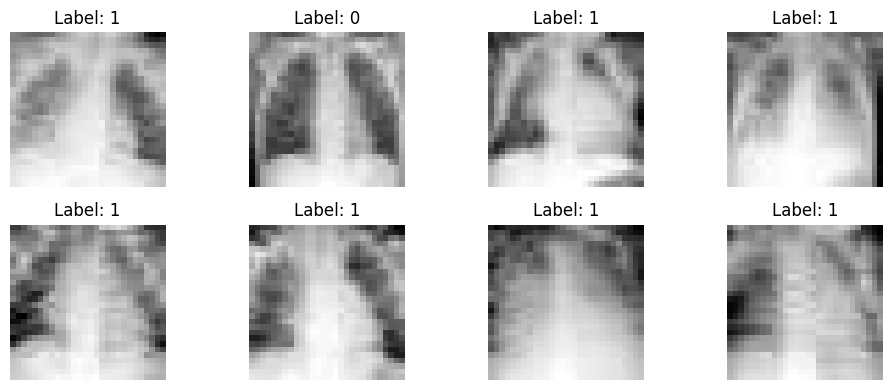

In [33]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    img = images[i].squeeze().numpy()
    label = labels[i].item()

    plt.imshow(img, cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [34]:
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super(PneumoniaCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = PneumoniaCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

PneumoniaCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [35]:
num_epochs = 5

train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

Epoch [1/5], Loss: 0.2824, Validation Accuracy: 0.9561
Epoch [2/5], Loss: 0.1474, Validation Accuracy: 0.9523
Epoch [3/5], Loss: 0.1105, Validation Accuracy: 0.9618
Epoch [4/5], Loss: 0.0932, Validation Accuracy: 0.9676
Epoch [5/5], Loss: 0.0887, Validation Accuracy: 0.9676


In [36]:
model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = correct / total

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.8638


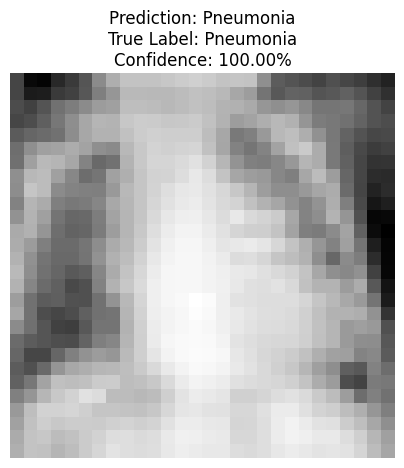

In [37]:
class_names = ["Normal", "Pneumonia"]

model.eval()

sample_image, sample_label = test_dataset[0]
input_image = sample_image.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_image)
    probabilities = torch.softmax(output, dim=1)
    predicted = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0, predicted].item()

# Convert image from normalized [-1, 1] back to [0, 1]
original_img = sample_image.squeeze().numpy()
original_img_display = (original_img * 0.5) + 0.5
original_img_display = np.clip(original_img_display, 0, 1)

plt.figure(figsize=(5, 5))
plt.imshow(original_img_display, cmap="gray")
plt.title(
    f"Prediction: {class_names[predicted]}\n"
    f"True Label: {class_names[sample_label.item()]}\n"
    f"Confidence: {confidence:.2%}"
)
plt.axis("off")
plt.savefig("outputs/sample_prediction.png", dpi=300, bbox_inches="tight")
plt.show()

## Grad-CAM

Grad-CAM shows which image regions contributed most to the model prediction.

It uses the gradients of the predicted class with respect to the final convolutional feature maps.

In [38]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_hook = target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image, class_idx=None):
        self.model.zero_grad()

        output = self.model(input_image)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        score = output[:, class_idx]
        score.backward()

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(dim=(2, 3), keepdim=True)

        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)

        cam = F.interpolate(
            cam,
            size=input_image.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, class_idx

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

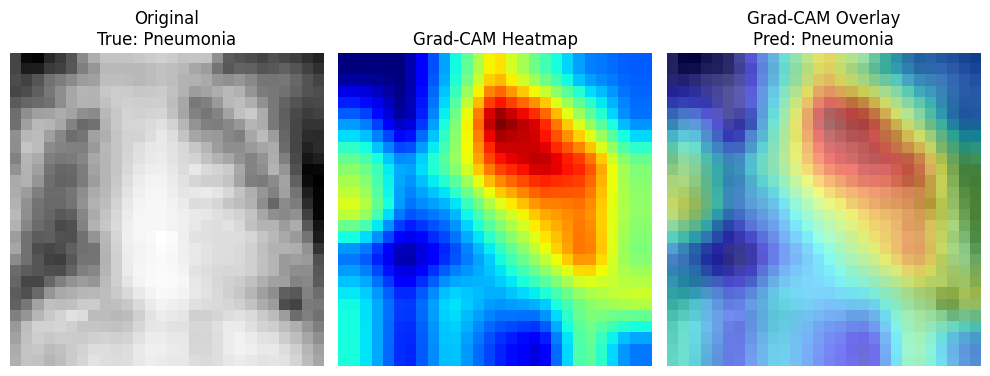

In [39]:
model.eval()

target_layer = model.features[-2]

gradcam = GradCAM(model, target_layer)
cam, gradcam_predicted_class = gradcam.generate(input_image)
gradcam.remove_hooks()

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_img_display, cmap="gray")
plt.title(f"Original\nTrue: {class_names[sample_label.item()]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(original_img_display, cmap="gray")
plt.imshow(cam, cmap="jet", alpha=0.5)
plt.title(f"Grad-CAM Overlay\nPred: {class_names[gradcam_predicted_class]}")
plt.axis("off")

plt.tight_layout()
plt.savefig("outputs/gradcam_result.png", dpi=300, bbox_inches="tight")
plt.show()

## LIME

LIME explains the prediction by changing small regions of the image and checking how the model prediction changes.

The highlighted regions are the local image areas that supported the predicted class.

In [40]:
def predict_lime(images):
    model.eval()

    images = np.array(images)

    # Convert RGB image to grayscale
    images = images[:, :, :, 0]

    # Add channel dimension: N, 1, H, W
    images = images[:, np.newaxis, :, :]

    images = torch.tensor(images, dtype=torch.float32)

    # Normalize from [0, 1] to [-1, 1]
    images = (images - 0.5) / 0.5

    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

    return probs.cpu().numpy()

  0%|          | 0/500 [00:00<?, ?it/s]

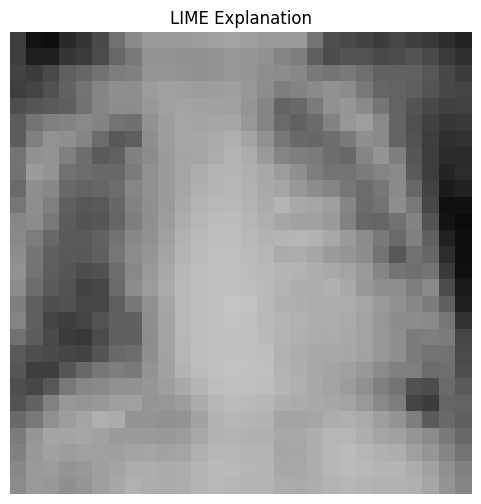

In [41]:
explainer = lime_image.LimeImageExplainer()

# Use clean display image in [0, 1]
lime_img = original_img_display

# LIME needs RGB image
lime_img_rgb = np.stack([lime_img, lime_img, lime_img], axis=-1)

explanation = explainer.explain_instance(
    lime_img_rgb,
    predict_lime,
    top_labels=2,
    hide_color=0,
    num_samples=500
)

temp, mask = explanation.get_image_and_mask(
    predicted,
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.figure(figsize=(6, 6))
plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation")
plt.axis("off")
plt.savefig("outputs/lime_result.png", dpi=300, bbox_inches="tight")
plt.show()